## sybil

###Imports + Load

In [1]:
import pandas as pd
import numpy as np
import csv

UDP_FILE  = "udp_packets.csv"
RSSI_FILE = "sniffer_frames.csv"

udp = pd.read_csv(UDP_FILE)

# Robust RSSI load (skips broken rows if any)
rssi = pd.read_csv(
    RSSI_FILE,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

udp.head(), rssi.head()


(   run_id                 scenario_id    ts_gateway       node_id  boot_id  \
 0     203  S1D_SYBIL_ONLY_HIGH_SIGNAL  1.772362e+09  ecg_01_clone    50681   
 1     203  S1D_SYBIL_ONLY_HIGH_SIGNAL  1.772362e+09  ecg_01_clone    50681   
 2     203  S1D_SYBIL_ONLY_HIGH_SIGNAL  1.772362e+09  ecg_01_clone    50681   
 3     203  S1D_SYBIL_ONLY_HIGH_SIGNAL  1.772362e+09  ecg_01_clone    50681   
 4     203  S1D_SYBIL_ONLY_HIGH_SIGNAL  1.772362e+09  ecg_01_clone    50681   
 
    seq   msg_type  payload_len       iat  seq_gap  seq_reset_flag  \
 0    0  ECG_SYBIL           30 -1.000000       -1               0   
 1    1  ECG_SYBIL           30  0.001327        1               0   
 2    2  ECG_SYBIL           30  0.003093        1               0   
 3    3  ECG_SYBIL           30  0.009639        1               0   
 4    4  ECG_SYBIL           30  0.010055        1               0   
 
    dup_seq_flag  out_of_order_flag  first_packet_flag  boot_change_flag  
 0             0           

###Clean + Convert types

In [2]:
# --- UDP cleaning ---
udp["ts_gateway"] = pd.to_numeric(udp["ts_gateway"], errors="coerce")
udp = udp.dropna(subset=["ts_gateway", "node_id"])

# Ensure numeric columns are numeric
num_cols_udp = [
    "boot_id","seq","payload_len","iat","seq_gap",
    "seq_reset_flag","dup_seq_flag","out_of_order_flag",
    "first_packet_flag","boot_change_flag"
]
for c in num_cols_udp:
    if c in udp.columns:
        udp[c] = pd.to_numeric(udp[c], errors="coerce")

# --- RSSI cleaning ---
rssi["ts_sniffer"] = pd.to_numeric(rssi["ts_sniffer"], errors="coerce")
rssi["rssi_dbm"]   = pd.to_numeric(rssi["rssi_dbm"], errors="coerce")
rssi["src_mac"]    = rssi["src_mac"].astype(str).str.lower()

rssi = rssi.dropna(subset=["ts_sniffer","src_mac","rssi_dbm"])

udp.shape, rssi.shape


((1012850, 15), (785180, 3))

###Align time to common start

In [3]:
start_time = max(udp["ts_gateway"].min(), rssi["ts_sniffer"].min())

udp["t"]  = udp["ts_gateway"]  - start_time
rssi["t"] = rssi["ts_sniffer"] - start_time

end_time = min(udp["t"].max(), rssi["t"].max())

start_time, end_time


(np.float64(1772361772.483525), np.float64(10077.516474962234))

###Provide node_id → MAC mapping (Phase A / stable mapping)


In [4]:
udp["boot_id"].value_counts().head(15)

boot_id
50681    1012850
Name: count, dtype: int64

In [10]:
rssi["src_mac"].value_counts().head(15)



src_mac
7c:9e:bd:f6:ce:48    664536
98:a9:42:17:7e:dc    102430
d8:d8:66:4f:d3:ea      9555
1c:b7:96:a3:78:a1      2793
ac:12:03:2f:4b:8f      1298
50:5a:65:ea:de:93      1050
50:2e:91:2c:3d:62       950
70:b5:e8:c6:b6:c1       617
7e:50:e1:0b:f6:4f       252
d8:d8:66:35:81:c7       214
98:a9:42:0a:a8:5c       162
f8:54:f6:15:f1:56       144
d4:1b:81:38:40:87       104
ec:2e:98:0b:10:c3       103
56:0d:04:f2:3a:79        44
Name: count, dtype: int64

In [11]:
# TODO: replace with your real mapping
node_to_mac = {
    "ecg_01_clone": "7c:9e:bd:f6:ce:48"
}
node_to_mac = {k: v.lower() for k,v in node_to_mac.items()}


###Window feature extraction (full)

In [12]:
WINDOW = 5.0   # seconds
STRIDE = 1.0   # seconds
MIN_RSSI_FRAMES = 5  # below this, treat RSSI as missing

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else np.nan

def safe_std(x):
    return float(np.nanstd(x)) if len(x) else np.nan

def extract_window_features(udp, rssi, node_to_mac, window=5.0, stride=1.0):
    rows = []
    win_starts = np.arange(0, end_time - window + 1e-9, stride)

    # sort once for speed/stability
    udp = udp.sort_values("t")
    rssi = rssi.sort_values("t")

    for node_id, mac in node_to_mac.items():
        mac = mac.lower()

        udp_node = udp[udp["node_id"] == node_id]
        rssi_node = rssi[rssi["src_mac"] == mac]

        for ws in win_starts:
            we = ws + window

            u = udp_node[(udp_node["t"] >= ws) & (udp_node["t"] < we)]
            s = rssi_node[(rssi_node["t"] >= ws) & (rssi_node["t"] < we)]

            # --- UDP features ---
            pps = len(u) / window
            iat_vals = u["iat"].to_numpy() if "iat" in u.columns else np.array([])
            iat_vals = iat_vals[iat_vals >= 0]  # ignore -1 placeholders

            seq_gap_vals = u["seq_gap"].to_numpy() if "seq_gap" in u.columns else np.array([])
            seq_gap_vals = seq_gap_vals[seq_gap_vals >= 0]

            def rate(col):
                if col not in u.columns or len(u) == 0:
                    return np.nan
                return float(np.nanmean(u[col].to_numpy()))

            # --- RSSI features ---
            rssi_vals = s["rssi_dbm"].to_numpy()
            rssi_count = len(rssi_vals)

            rssi_missing = 1 if rssi_count < MIN_RSSI_FRAMES else 0

            rows.append({
                "node_id": node_id,
                "node_mac": mac,
                "window_start_s": float(ws),
                "window_end_s": float(we),

                # UDP
                "pps": float(pps),
                "iat_mean": safe_mean(iat_vals),
                "iat_std": safe_std(iat_vals),
                "seq_gap_mean": safe_mean(seq_gap_vals),
                "seq_gap_max": float(np.nanmax(seq_gap_vals)) if len(seq_gap_vals) else np.nan,
                "seq_reset_rate": rate("seq_reset_flag"),
                "dup_seq_rate": rate("dup_seq_flag"),
                "out_of_order_rate": rate("out_of_order_flag"),
                "boot_change_rate": rate("boot_change_flag"),
                "udp_pkt_count": int(len(u)),

                # RSSI
                "rssi_mean": safe_mean(rssi_vals),
                "rssi_std": safe_std(rssi_vals),
                "rssi_min": float(np.nanmin(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_max": float(np.nanmax(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_frame_count": int(rssi_count),
                "rssi_missing": int(rssi_missing),
            })

    return pd.DataFrame(rows)

features = extract_window_features(udp, rssi, node_to_mac, window=WINDOW, stride=STRIDE)
features.head(), features.shape


(        node_id           node_mac  window_start_s  window_end_s    pps  \
 0  ecg_01_clone  7c:9e:bd:f6:ce:48             0.0           5.0  100.4   
 1  ecg_01_clone  7c:9e:bd:f6:ce:48             1.0           6.0  100.0   
 2  ecg_01_clone  7c:9e:bd:f6:ce:48             2.0           7.0  100.0   
 3  ecg_01_clone  7c:9e:bd:f6:ce:48             3.0           8.0  100.0   
 4  ecg_01_clone  7c:9e:bd:f6:ce:48             4.0           9.0  100.0   
 
    iat_mean   iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  \
 0  0.009969  0.004773          1.02          7.0             0.0   
 1  0.010004  0.001811          1.00          1.0             0.0   
 2  0.009999  0.001802          1.00          1.0             0.0   
 3  0.010001  0.001816          1.00          1.0             0.0   
 4  0.010000  0.001854          1.00          1.0             0.0   
 
    dup_seq_rate  out_of_order_rate  boot_change_rate  udp_pkt_count  \
 0           0.0           0.001992               0.0 

Fill missing RSSI values

In [13]:
# Fill missing RSSI values when RSSI is missing
features["rssi_mean"] = features["rssi_mean"].fillna(-100)
features["rssi_std"]  = features["rssi_std"].fillna(0)
features["rssi_min"]  = features["rssi_min"].fillna(-100)
features["rssi_max"]  = features["rssi_max"].fillna(-100)

# Fill missing UDP stats too (rare)
features["iat_mean"] = features["iat_mean"].fillna(-1)
features["iat_std"]  = features["iat_std"].fillna(-1)
features["seq_gap_mean"] = features["seq_gap_mean"].fillna(-1)
features["seq_gap_max"]  = features["seq_gap_max"].fillna(-1)

features.isna().sum().sort_values(ascending=False).head(10)


node_id           0
node_mac          0
window_start_s    0
window_end_s      0
pps               0
iat_mean          0
iat_std           0
seq_gap_mean      0
seq_gap_max       0
seq_reset_rate    0
dtype: int64

Save and download

In [14]:
OUT_FILE = "phaseA_window_features.csv"
features.to_csv(OUT_FILE, index=False)


### rssi + udp


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "phaseA_window_features.csv"   # change if your file name differs
df = pd.read_csv(FILE)

df.head(), df.shape


(        node_id           node_mac  window_start_s  window_end_s    pps  \
 0  ecg_01_clone  7c:9e:bd:f6:ce:48             0.0           5.0  100.4   
 1  ecg_01_clone  7c:9e:bd:f6:ce:48             1.0           6.0  100.0   
 2  ecg_01_clone  7c:9e:bd:f6:ce:48             2.0           7.0  100.0   
 3  ecg_01_clone  7c:9e:bd:f6:ce:48             3.0           8.0  100.0   
 4  ecg_01_clone  7c:9e:bd:f6:ce:48             4.0           9.0  100.0   
 
    iat_mean   iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  \
 0  0.009969  0.004773          1.02          7.0             0.0   
 1  0.010004  0.001811          1.00          1.0             0.0   
 2  0.009999  0.001802          1.00          1.0             0.0   
 3  0.010001  0.001816          1.00          1.0             0.0   
 4  0.010000  0.001854          1.00          1.0             0.0   
 
    dup_seq_rate  out_of_order_rate  boot_change_rate  udp_pkt_count  \
 0           0.0           0.001992               0.0 

Select only feature columns (numeric)

In [16]:
# Columns you usually do NOT want as features
exclude = {"node_id","node_mac","window_start_s","window_end_s"}

num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

num_cols


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

Histogram for each feature (one-by-one)

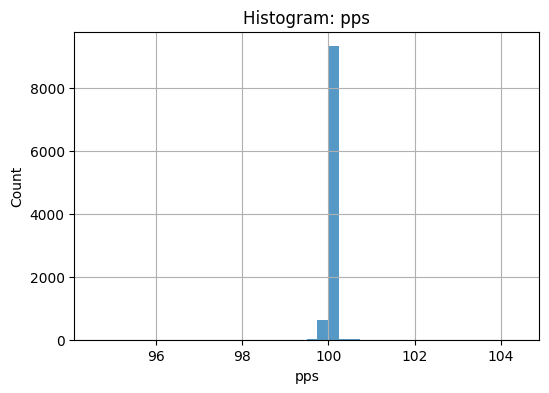

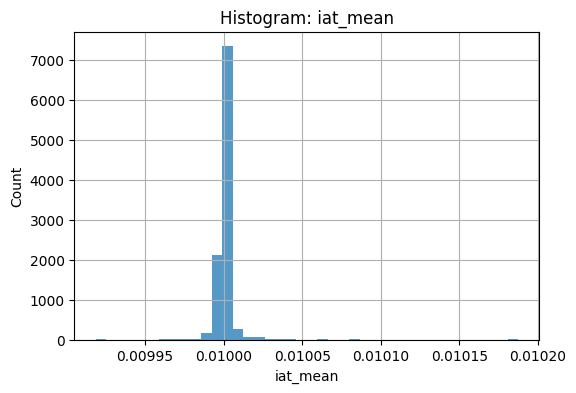

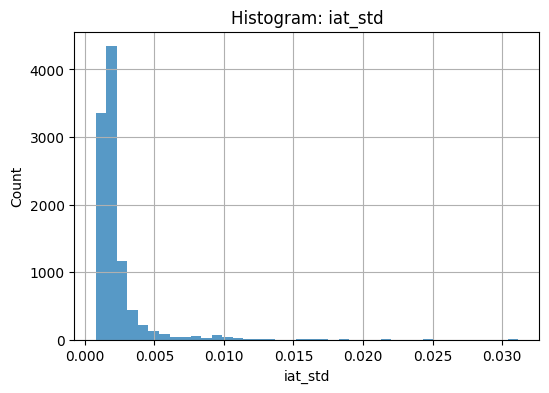

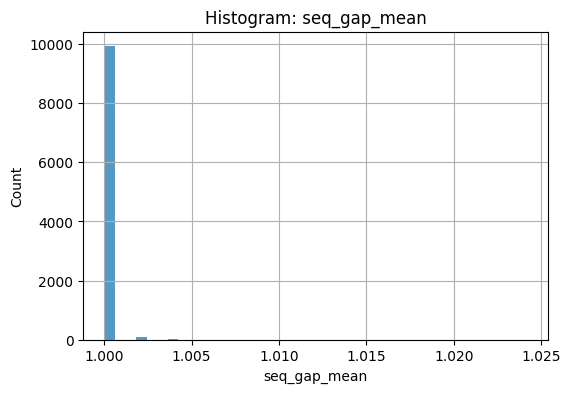

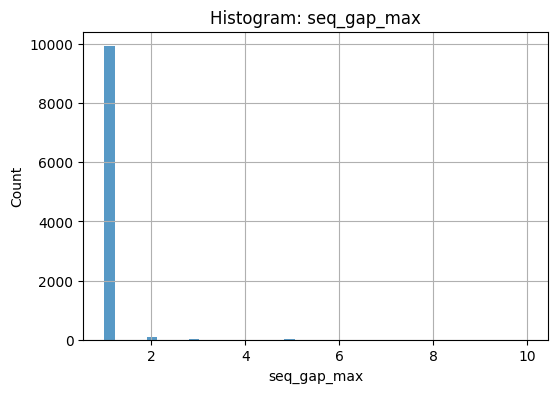

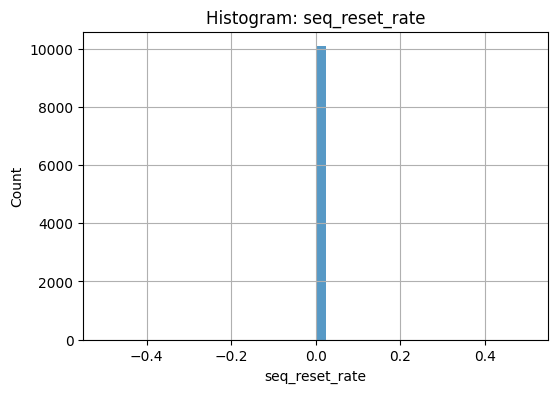

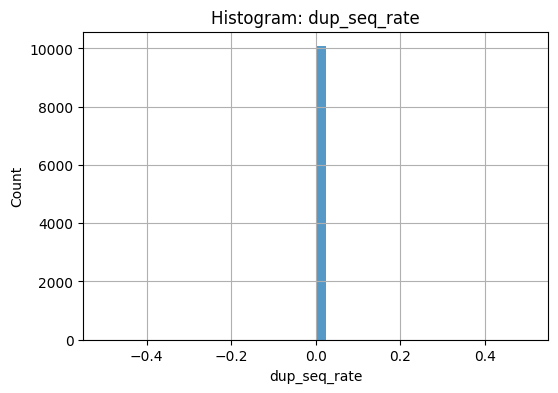

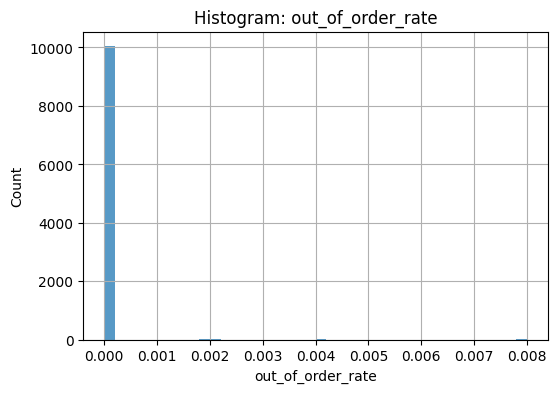

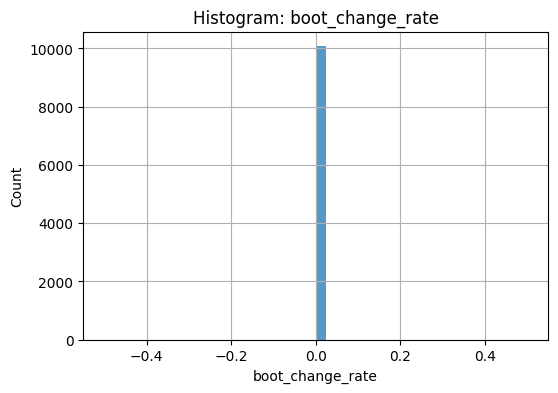

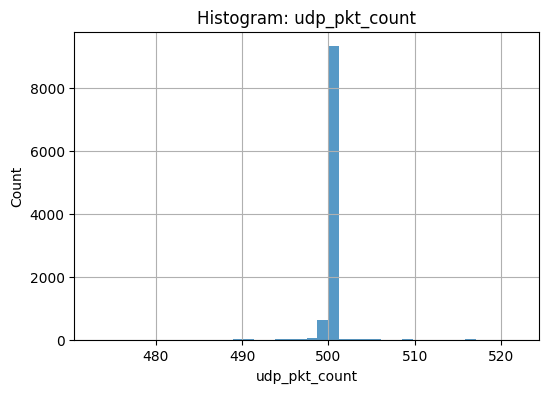

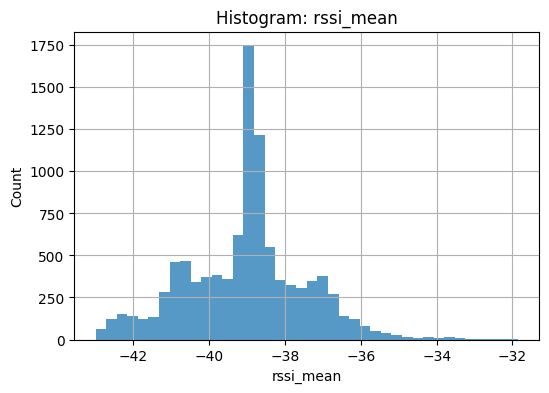

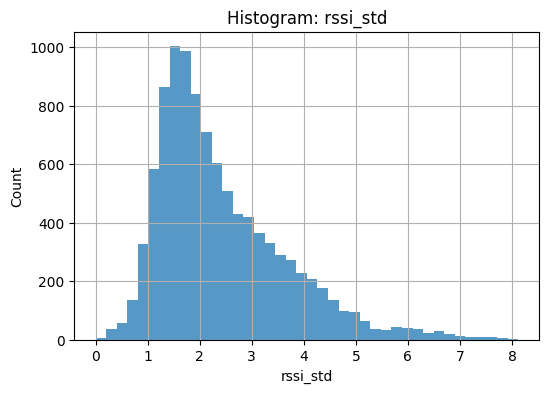

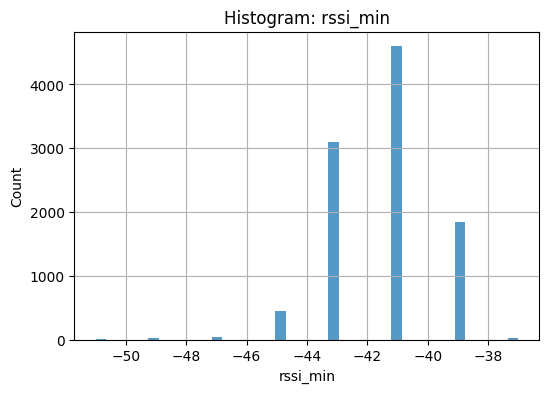

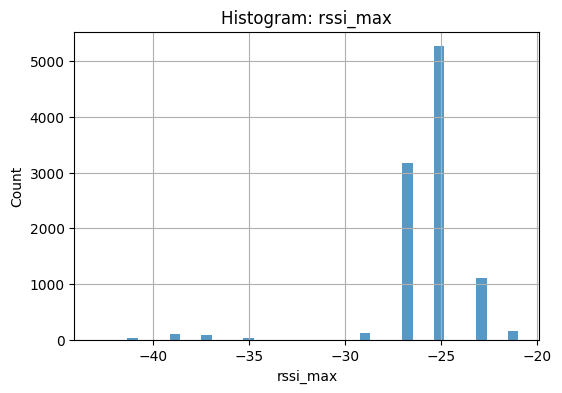

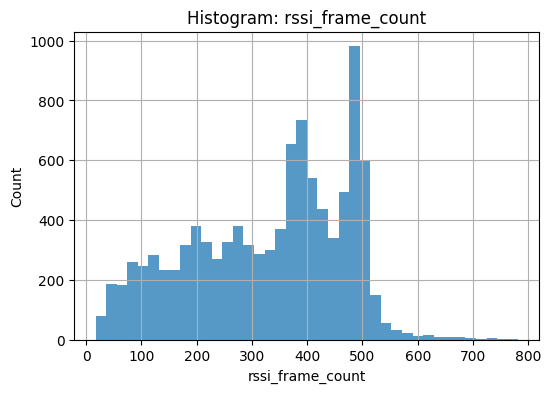

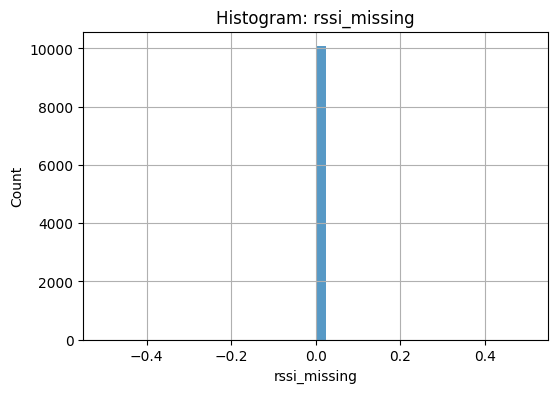

In [17]:
for col in num_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6,4))
    plt.hist(x, bins=40, alpha=0.75)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


Histogram per node_id

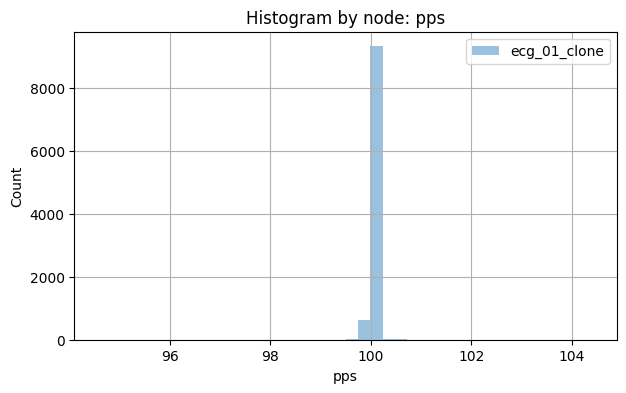

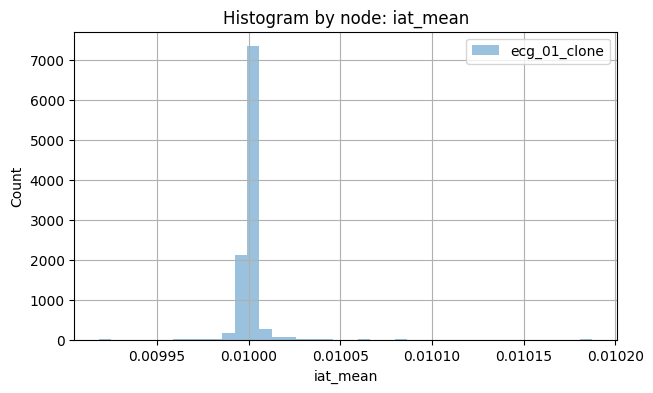

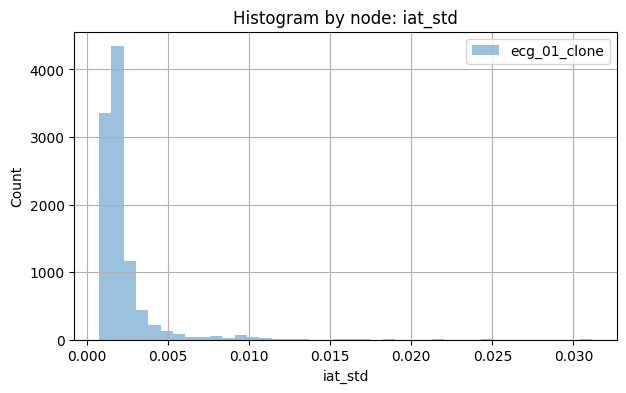

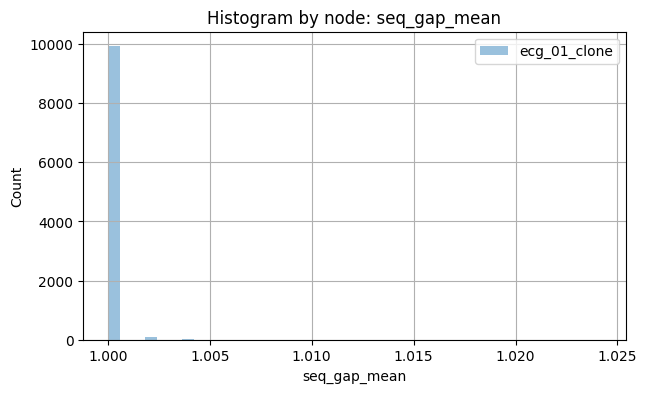

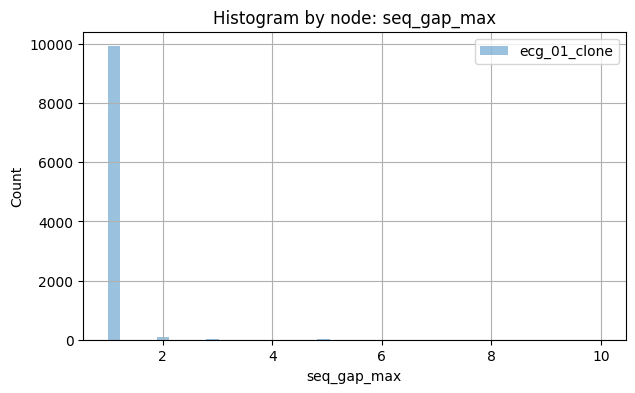

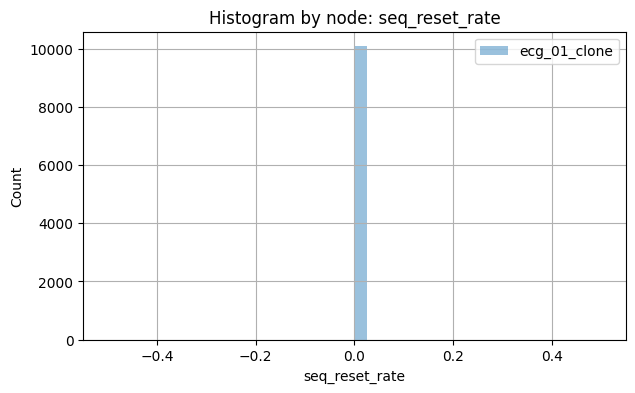

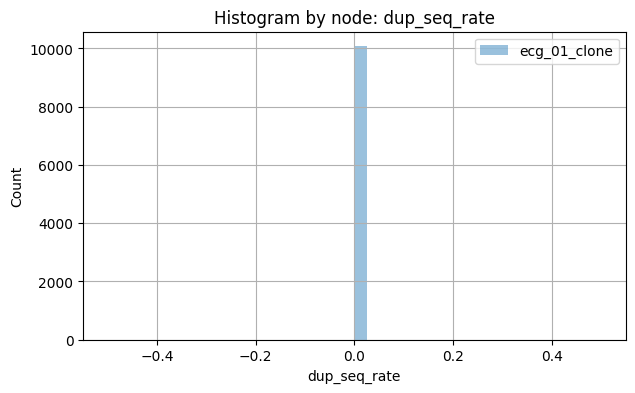

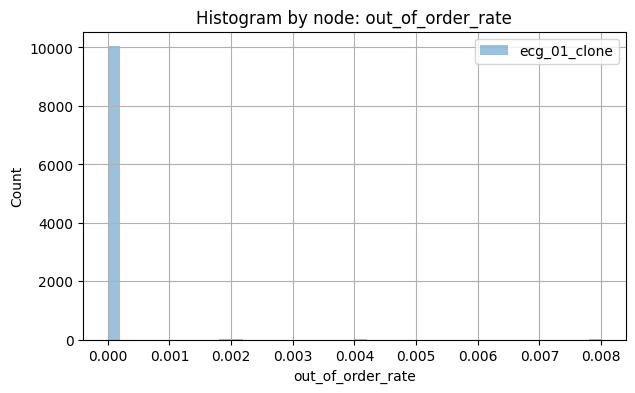

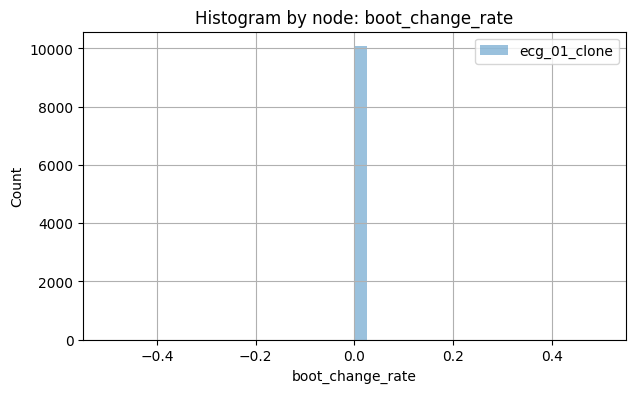

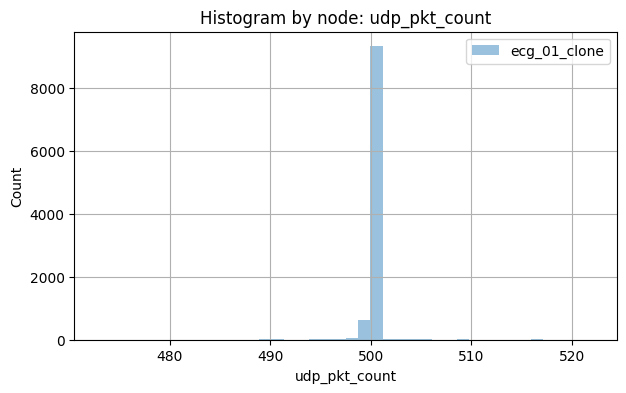

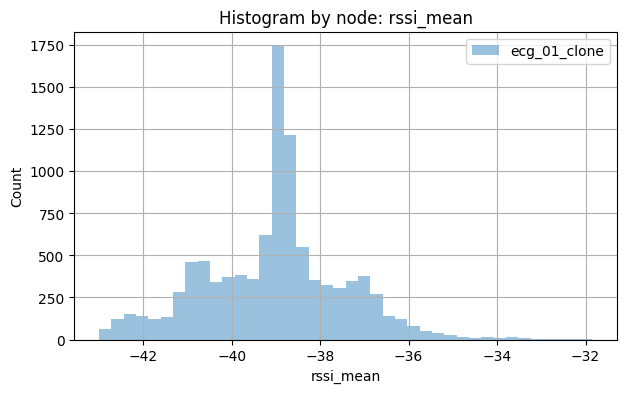

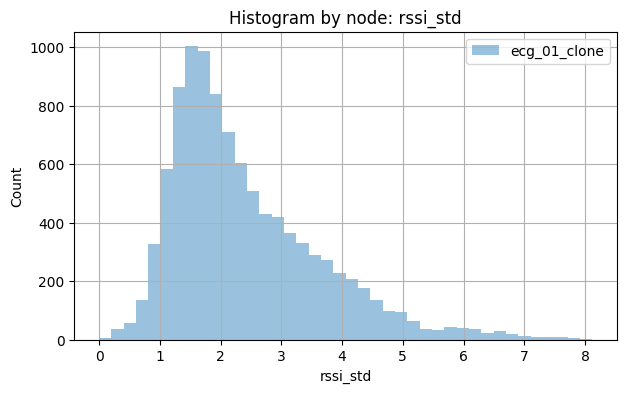

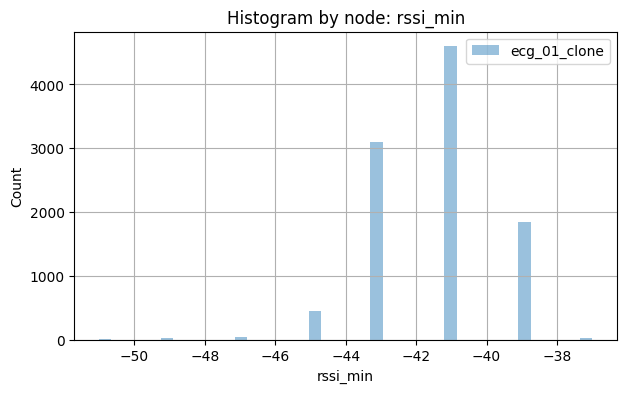

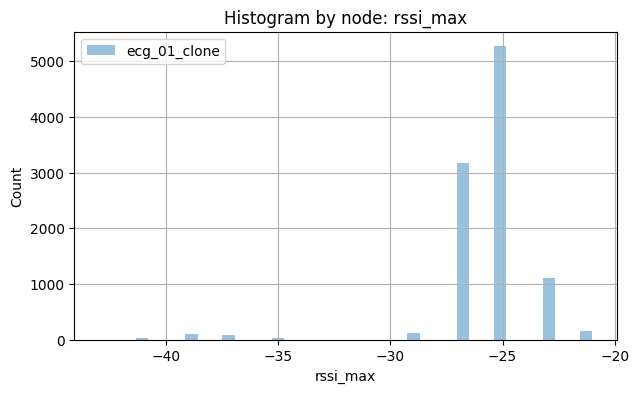

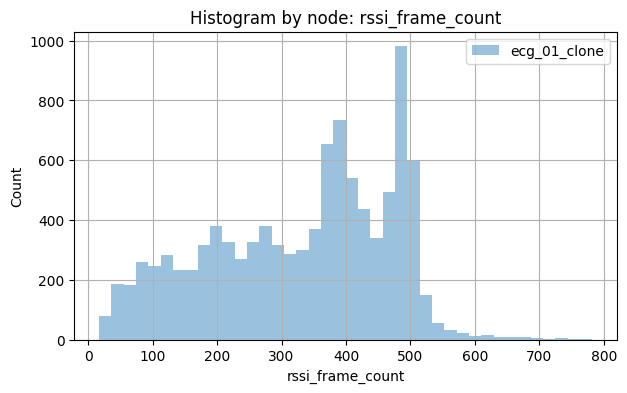

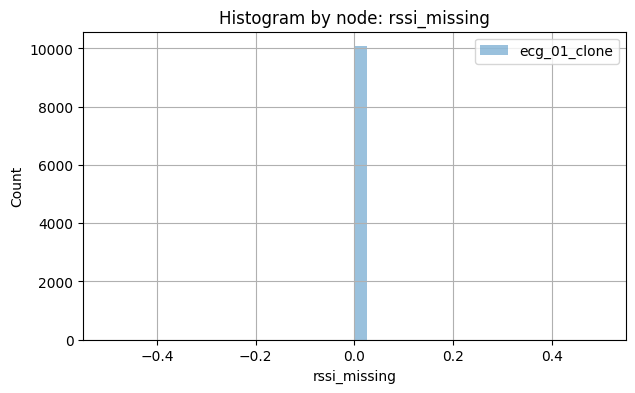

In [18]:
nodes = df["node_id"].unique().tolist()

for col in num_cols:
    plt.figure(figsize=(7,4))
    for n in nodes:
        x = df[df["node_id"] == n][col].dropna()
        if len(x) == 0:
            continue
        plt.hist(x, bins=40, alpha=0.45, label=n)

    plt.title(f"Histogram by node: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()


quality checks

In [19]:
# Missing values per column
df[num_cols].isna().mean().sort_values(ascending=False).head(15)


pps                  0.0
iat_mean             0.0
iat_std              0.0
seq_gap_mean         0.0
seq_gap_max          0.0
seq_reset_rate       0.0
dup_seq_rate         0.0
out_of_order_rate    0.0
boot_change_rate     0.0
udp_pkt_count        0.0
rssi_mean            0.0
rssi_std             0.0
rssi_min             0.0
rssi_max             0.0
rssi_frame_count     0.0
dtype: float64

In [20]:
# Basic stats
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pps,10073.0,99.995771,0.191463,94.600000,100.000000,100.000000,100.000000,104.400000
iat_mean,10073.0,0.010000,0.000007,0.009918,0.009999,0.010000,0.010001,0.010187
iat_std,10073.0,0.002224,0.001836,0.000773,0.001420,0.001770,0.002248,0.031156
seq_gap_mean,10073.0,1.000076,0.000958,1.000000,1.000000,1.000000,1.000000,1.024194
seq_gap_max,10073.0,1.027301,0.306063,1.000000,1.000000,1.000000,1.000000,10.000000
seq_reset_rate,10073.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
dup_seq_rate,10073.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
out_of_order_rate,10073.0,0.000010,0.000206,0.000000,0.000000,0.000000,0.000000,0.008000
boot_change_rate,10073.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
udp_pkt_count,10073.0,499.978854,0.957315,473.000000,500.000000,500.000000,500.000000,522.000000


In [21]:
# RSSI missing rate (important if you use RSSI)
if "rssi_missing" in df.columns:
    print(df["rssi_missing"].value_counts(normalize=True))


rssi_missing
0    1.0
Name: proportion, dtype: float64


###label sybil

In [22]:
df["label"] = 1

In [23]:
df["label"].value_counts()


label
1    10073
Name: count, dtype: int64

In [24]:
df.to_csv("window_features_sybil_sybil_labeled.csv", index=False)



##Normal



In [25]:
import pandas as pd
import numpy as np
import csv

UDP_FILE  = "udp_packets1.csv"
RSSI_FILE = "sniffer_frames1.csv"

udp = pd.read_csv(UDP_FILE)

# Robust RSSI load (skips broken rows if any)
rssi = pd.read_csv(
    RSSI_FILE,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

udp.head(), rssi.head()


(   run_id scenario_id    ts_gateway node_id  boot_id  seq msg_type  \
 0       1   S0_NORMAL  1.770961e+09  ecg_01    22964    0      ECG   
 1       1   S0_NORMAL  1.770961e+09  ecg_01    22964    1      ECG   
 2       1   S0_NORMAL  1.770961e+09  ecg_01    22964    2      ECG   
 3       1   S0_NORMAL  1.770961e+09  ecg_01    22964    3      ECG   
 4       1   S0_NORMAL  1.770961e+09  ecg_01    22964    4      ECG   
 
    payload_len       iat  seq_gap  seq_reset_flag  dup_seq_flag  \
 0           18 -1.000000       -1               0             0   
 1           18  0.090622        1               0             0   
 2           18  0.101155        1               0             0   
 3           18  0.098227        1               0             0   
 4           18  0.100146        1               0             0   
 
    out_of_order_flag  first_packet_flag  boot_change_flag  
 0                  0                  1                 0  
 1                  0                  0

In [26]:
# --- UDP cleaning ---
udp["ts_gateway"] = pd.to_numeric(udp["ts_gateway"], errors="coerce")
udp = udp.dropna(subset=["ts_gateway", "node_id"])

# Ensure numeric columns are numeric
num_cols_udp = [
    "boot_id","seq","payload_len","iat","seq_gap",
    "seq_reset_flag","dup_seq_flag","out_of_order_flag",
    "first_packet_flag","boot_change_flag"
]
for c in num_cols_udp:
    if c in udp.columns:
        udp[c] = pd.to_numeric(udp[c], errors="coerce")

# --- RSSI cleaning ---
rssi["ts_sniffer"] = pd.to_numeric(rssi["ts_sniffer"], errors="coerce")
rssi["rssi_dbm"]   = pd.to_numeric(rssi["rssi_dbm"], errors="coerce")
rssi["src_mac"]    = rssi["src_mac"].astype(str).str.lower()

rssi = rssi.dropna(subset=["ts_sniffer","src_mac","rssi_dbm"])

udp.shape, rssi.shape


((450745, 15), (2620611, 3))

In [27]:
start_time = max(udp["ts_gateway"].min(), rssi["ts_sniffer"].min())

udp["t"]  = udp["ts_gateway"]  - start_time
rssi["t"] = rssi["ts_sniffer"] - start_time

end_time = min(udp["t"].max(), rssi["t"].max())

start_time, end_time


(np.float64(1770961145.606577), np.float64(17980.46187210083))

In [28]:
udp["node_id"].value_counts().head(15)

node_id
eeg_01    301219
ecg_01    149526
Name: count, dtype: int64

In [29]:
rssi["src_mac"].value_counts().head(15)


src_mac
f8:89:d2:52:07:81    945803
98:a9:42:17:7e:dc    834804
08:d1:f9:e8:84:c0    434964
84:1f:e8:36:62:98    232548
d8:d8:66:4d:b9:1c     50036
d8:42:f7:50:ea:0d     48546
1c:b7:96:a3:78:a1     17214
d8:d8:66:35:f2:66     11150
98:a9:42:09:aa:f1      9746
98:a9:42:ab:54:9e      6330
d8:d8:66:4f:d3:ea      5370
70:b5:e8:c6:b6:c1      5022
18:d9:8f:2d:46:64      4845
f4:cb:52:f8:3d:f1      1868
90:61:0c:5a:de:d1      1685
Name: count, dtype: int64

In [30]:
# TODO: replace with your real mapping
node_to_mac = {
    "ecg_01": "84:1f:e8:36:62:98",
    "eeg_01": "08:d1:f9:e8:84:c0",
}
node_to_mac = {k: v.lower() for k,v in node_to_mac.items()}


In [31]:
WINDOW = 5.0   # seconds
STRIDE = 1.0   # seconds
MIN_RSSI_FRAMES = 5  # below this, treat RSSI as missing

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else np.nan

def safe_std(x):
    return float(np.nanstd(x)) if len(x) else np.nan

def extract_window_features(udp, rssi, node_to_mac, window=5.0, stride=1.0):
    rows = []
    win_starts = np.arange(0, end_time - window + 1e-9, stride)

    # sort once for speed/stability
    udp = udp.sort_values("t")
    rssi = rssi.sort_values("t")

    for node_id, mac in node_to_mac.items():
        mac = mac.lower()

        udp_node = udp[udp["node_id"] == node_id]
        rssi_node = rssi[rssi["src_mac"] == mac]

        for ws in win_starts:
            we = ws + window

            u = udp_node[(udp_node["t"] >= ws) & (udp_node["t"] < we)]
            s = rssi_node[(rssi_node["t"] >= ws) & (rssi_node["t"] < we)]

            # --- UDP features ---
            pps = len(u) / window
            iat_vals = u["iat"].to_numpy() if "iat" in u.columns else np.array([])
            iat_vals = iat_vals[iat_vals >= 0]  # ignore -1 placeholders

            seq_gap_vals = u["seq_gap"].to_numpy() if "seq_gap" in u.columns else np.array([])
            seq_gap_vals = seq_gap_vals[seq_gap_vals >= 0]

            def rate(col):
                if col not in u.columns or len(u) == 0:
                    return np.nan
                return float(np.nanmean(u[col].to_numpy()))

            # --- RSSI features ---
            rssi_vals = s["rssi_dbm"].to_numpy()
            rssi_count = len(rssi_vals)

            rssi_missing = 1 if rssi_count < MIN_RSSI_FRAMES else 0

            rows.append({
                "node_id": node_id,
                "node_mac": mac,
                "window_start_s": float(ws),
                "window_end_s": float(we),

                # UDP
                "pps": float(pps),
                "iat_mean": safe_mean(iat_vals),
                "iat_std": safe_std(iat_vals),
                "seq_gap_mean": safe_mean(seq_gap_vals),
                "seq_gap_max": float(np.nanmax(seq_gap_vals)) if len(seq_gap_vals) else np.nan,
                "seq_reset_rate": rate("seq_reset_flag"),
                "dup_seq_rate": rate("dup_seq_flag"),
                "out_of_order_rate": rate("out_of_order_flag"),
                "boot_change_rate": rate("boot_change_flag"),
                "udp_pkt_count": int(len(u)),

                # RSSI
                "rssi_mean": safe_mean(rssi_vals),
                "rssi_std": safe_std(rssi_vals),
                "rssi_min": float(np.nanmin(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_max": float(np.nanmax(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_frame_count": int(rssi_count),
                "rssi_missing": int(rssi_missing),
            })

    return pd.DataFrame(rows)

features = extract_window_features(udp, rssi, node_to_mac, window=WINDOW, stride=STRIDE)
features.head(), features.shape


(  node_id           node_mac  window_start_s  window_end_s   pps  iat_mean  \
 0  ecg_01  84:1f:e8:36:62:98             0.0           5.0  10.2  0.099802   
 1  ecg_01  84:1f:e8:36:62:98             1.0           6.0  10.0  0.099973   
 2  ecg_01  84:1f:e8:36:62:98             2.0           7.0  10.0  0.099998   
 3  ecg_01  84:1f:e8:36:62:98             3.0           8.0  10.0  0.099951   
 4  ecg_01  84:1f:e8:36:62:98             4.0           9.0  10.0  0.099969   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.002997           1.0          1.0             0.0           0.0   
 1  0.002757           1.0          1.0             0.0           0.0   
 2  0.002671           1.0          1.0             0.0           0.0   
 3  0.002660           1.0          1.0             0.0           0.0   
 4  0.001191           1.0          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean  rssi_std  \
 0   

In [32]:
# Fill missing RSSI values when RSSI is missing
features["rssi_mean"] = features["rssi_mean"].fillna(-100)
features["rssi_std"]  = features["rssi_std"].fillna(0)
features["rssi_min"]  = features["rssi_min"].fillna(-100)
features["rssi_max"]  = features["rssi_max"].fillna(-100)

# Fill missing UDP stats too (rare)
features["iat_mean"] = features["iat_mean"].fillna(-1)
features["iat_std"]  = features["iat_std"].fillna(-1)
features["seq_gap_mean"] = features["seq_gap_mean"].fillna(-1)
features["seq_gap_max"]  = features["seq_gap_max"].fillna(-1)

features.isna().sum().sort_values(ascending=False).head(10)


boot_change_rate     5554
seq_reset_rate       5554
out_of_order_rate    5554
dup_seq_rate         5554
window_end_s            0
window_start_s          0
node_mac                0
node_id                 0
seq_gap_mean            0
iat_std                 0
dtype: int64

In [33]:
OUT_FILE = "phaseA_window_features1.csv"
features.to_csv(OUT_FILE, index=False)


In [34]:
features["rssi_missing"].value_counts(normalize=True)


rssi_missing
0    0.761543
1    0.238457
Name: proportion, dtype: float64

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "phaseA_window_features1.csv"   # change if your file name differs
df = pd.read_csv(FILE)

df.head(), df.shape


(  node_id           node_mac  window_start_s  window_end_s   pps  iat_mean  \
 0  ecg_01  84:1f:e8:36:62:98             0.0           5.0  10.2  0.099802   
 1  ecg_01  84:1f:e8:36:62:98             1.0           6.0  10.0  0.099973   
 2  ecg_01  84:1f:e8:36:62:98             2.0           7.0  10.0  0.099998   
 3  ecg_01  84:1f:e8:36:62:98             3.0           8.0  10.0  0.099951   
 4  ecg_01  84:1f:e8:36:62:98             4.0           9.0  10.0  0.099969   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.002997           1.0          1.0             0.0           0.0   
 1  0.002757           1.0          1.0             0.0           0.0   
 2  0.002671           1.0          1.0             0.0           0.0   
 3  0.002660           1.0          1.0             0.0           0.0   
 4  0.001191           1.0          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean  rssi_std  \
 0   

In [36]:
# Columns you usually do NOT want as features
exclude = {"node_id","node_mac","window_start_s","window_end_s"}

num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

num_cols


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

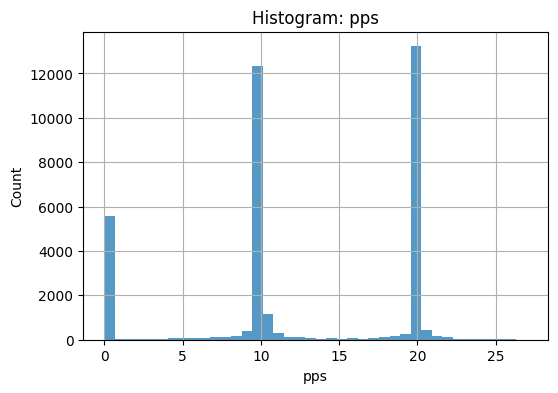

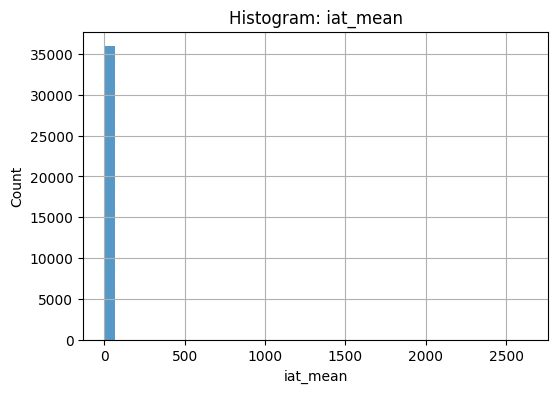

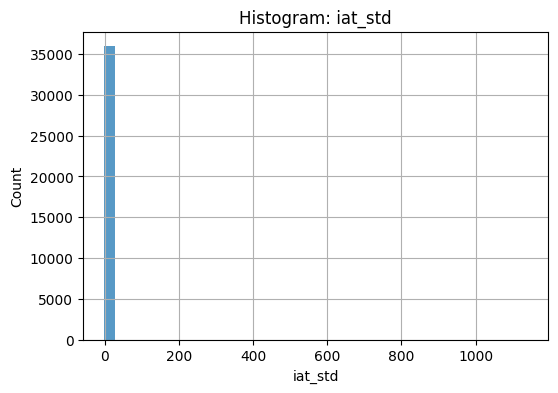

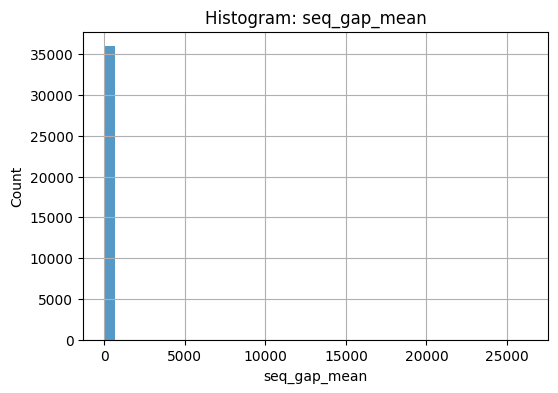

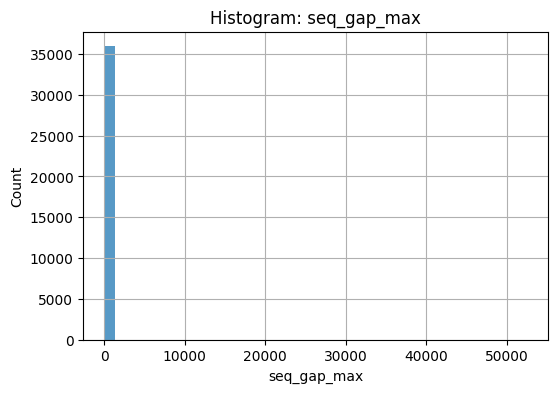

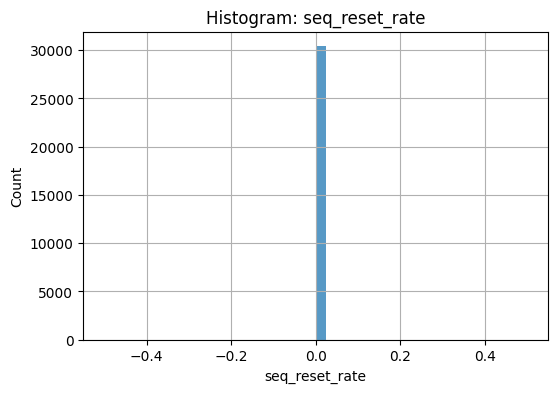

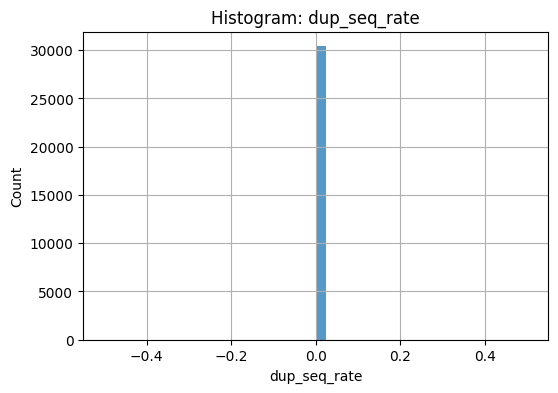

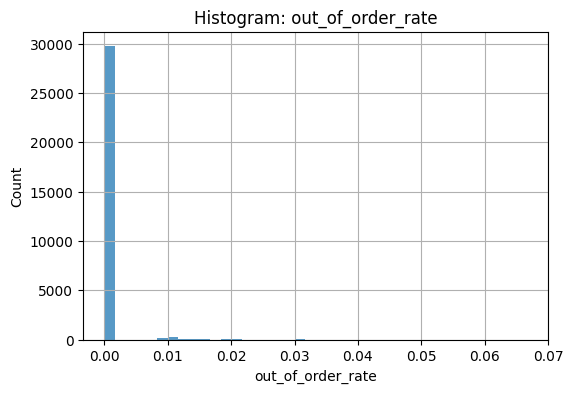

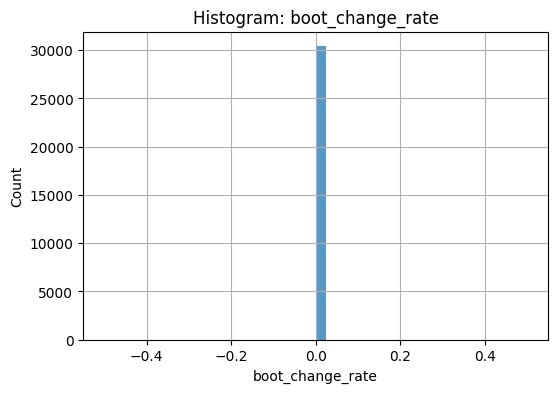

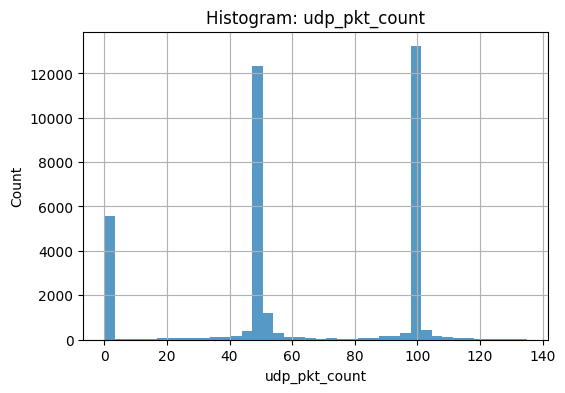

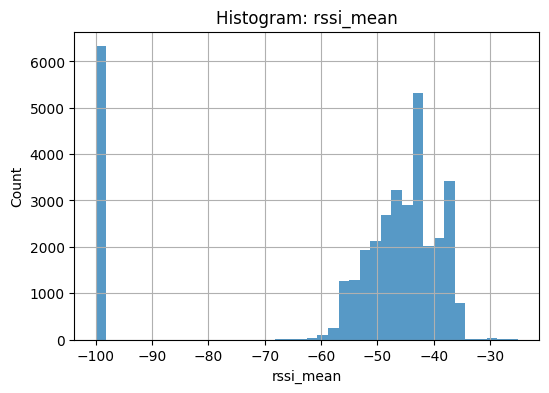

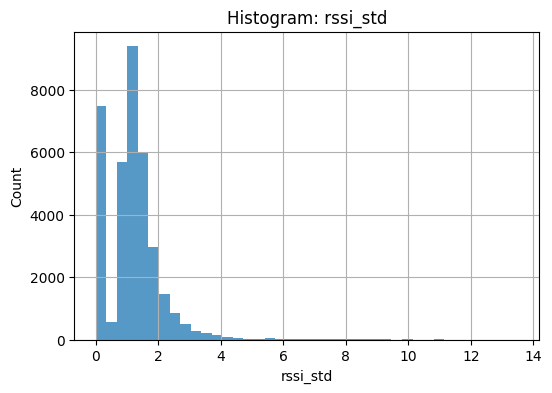

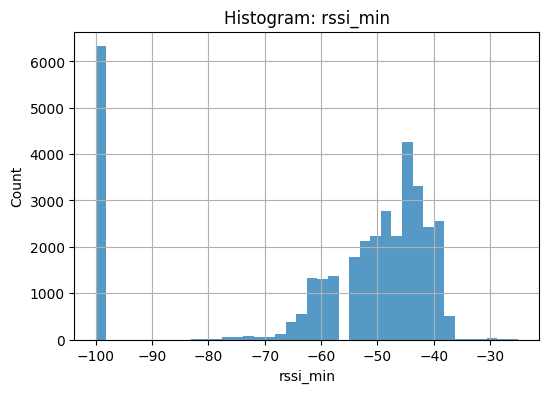

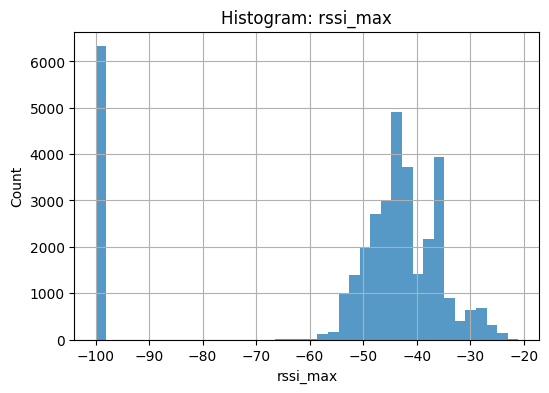

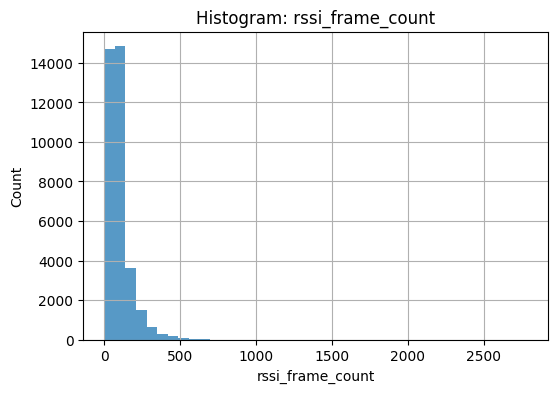

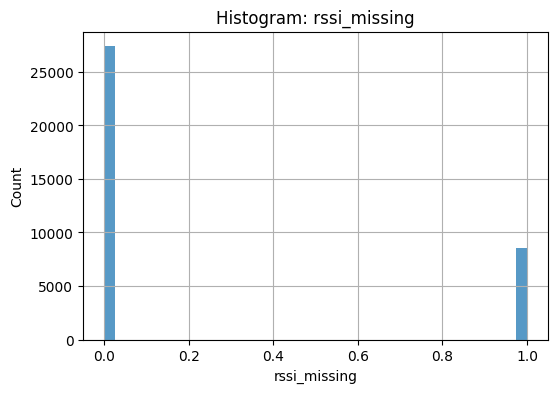

In [37]:
for col in num_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6,4))
    plt.hist(x, bins=40, alpha=0.75)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


### normal label

In [38]:
df["label"] = 0

In [39]:
df["label"].value_counts()


label
0    35952
Name: count, dtype: int64

In [40]:
df.to_csv("window_features_normal_labeled.csv", index=False)

In [41]:
normal = pd.read_csv("window_features_normal_labeled.csv")
sybil  = pd.read_csv("window_features_sybil_sybil_labeled.csv")

full = pd.concat([normal, sybil], ignore_index=True)
full.to_csv("dataset_all_labeled.csv", index=False)


In [42]:
files.download("dataset_all_labeled.csv")

NameError: name 'files' is not defined

## sybil+ normal


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "dataset_all_labeled.csv"   # change to your file name
df = pd.read_csv(FILE)

df["label"].value_counts()


label
0    35952
1    10073
Name: count, dtype: int64

Select numeric feature columns

In [44]:
exclude = {
    "node_id","node_mac",
    "window_start_s","window_end_s",
    "label"
}

features = [
    c for c in df.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
]

features


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

Plot Normal vs Sybil histograms (main analysis)

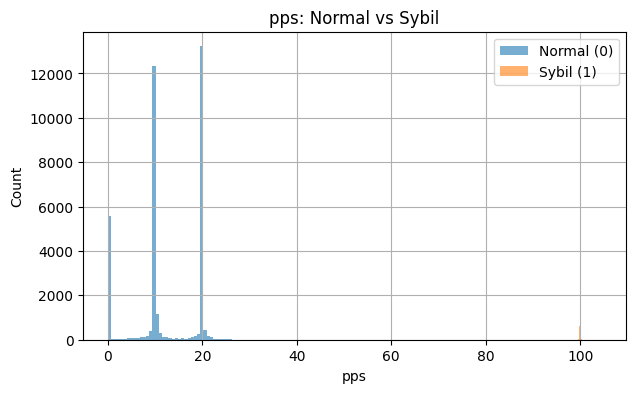

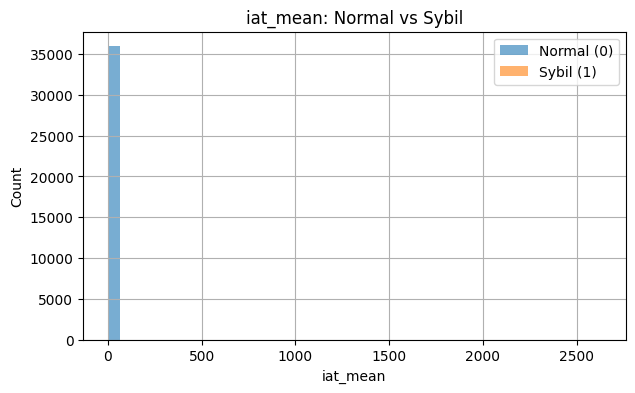

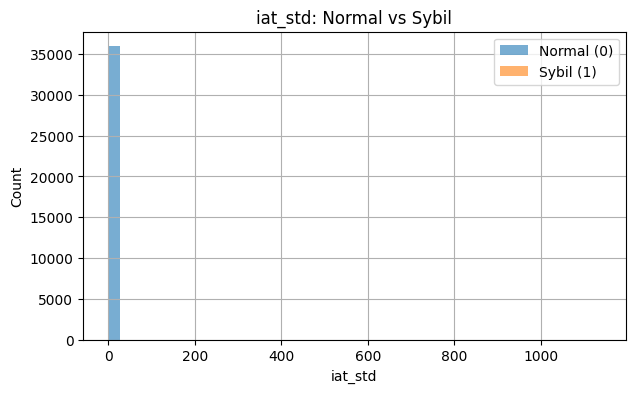

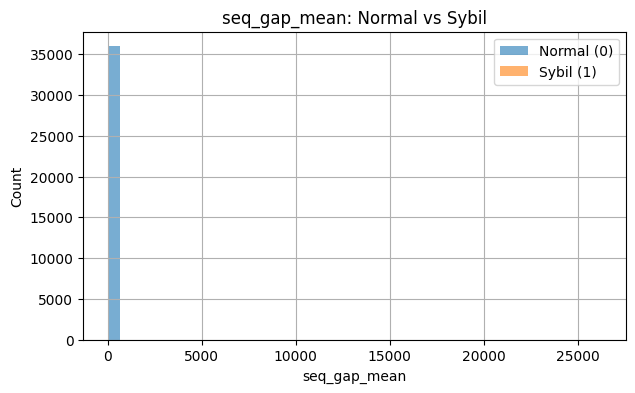

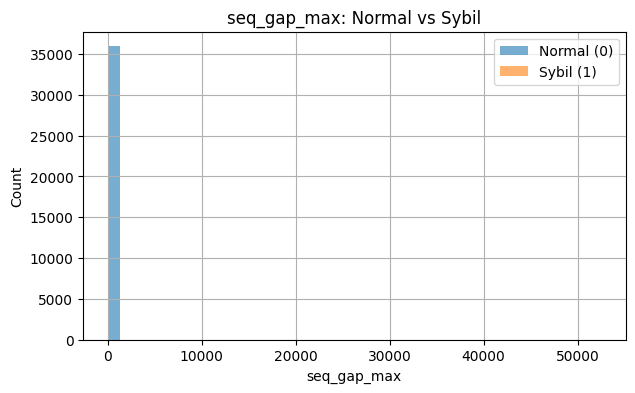

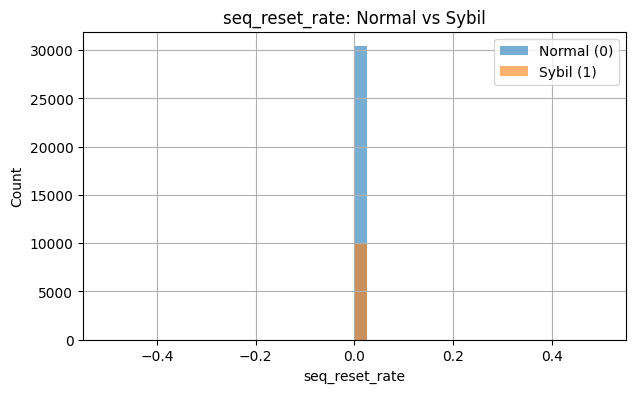

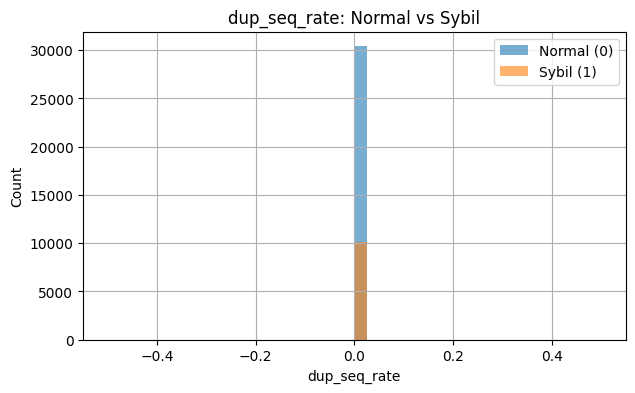

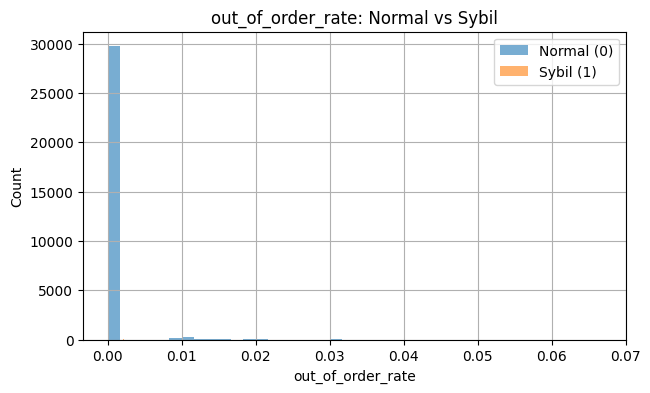

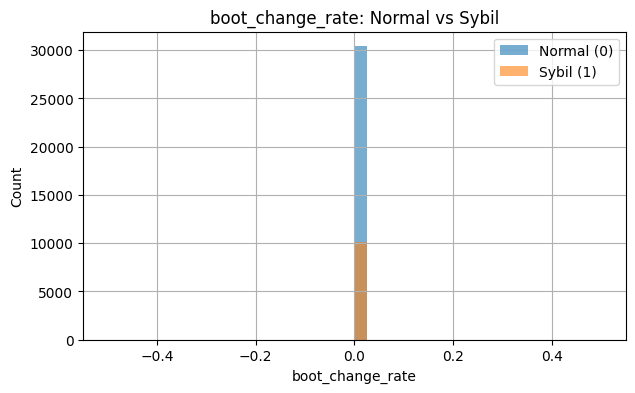

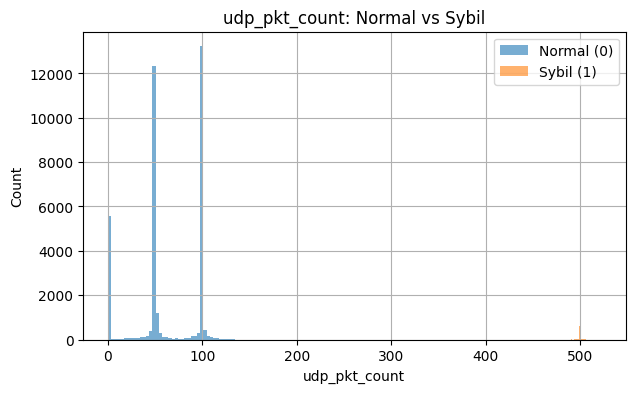

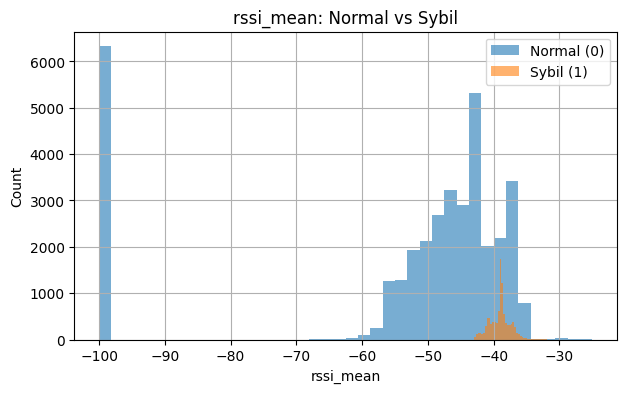

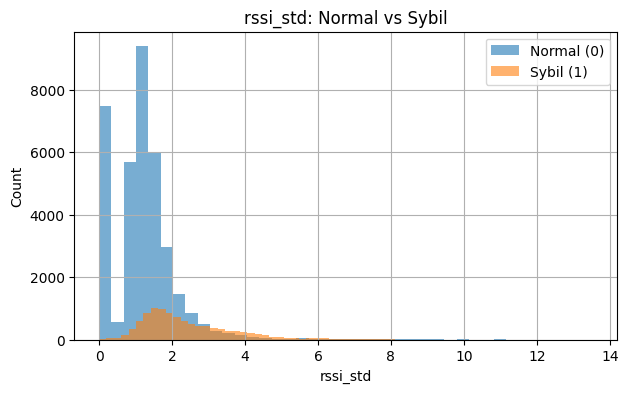

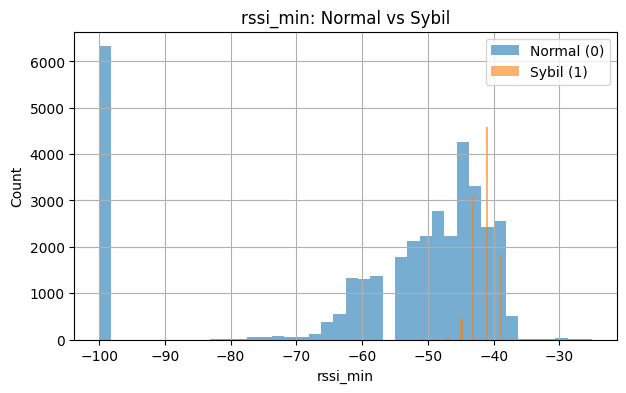

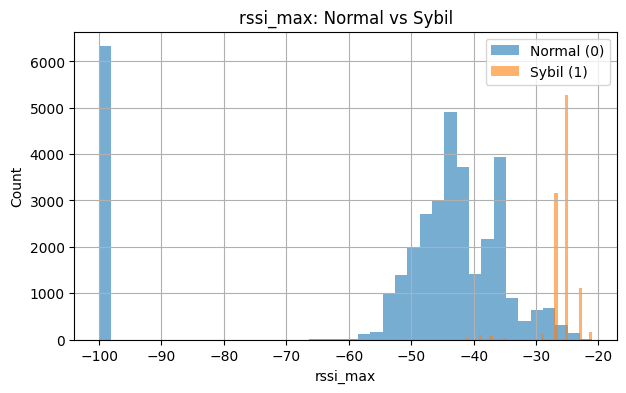

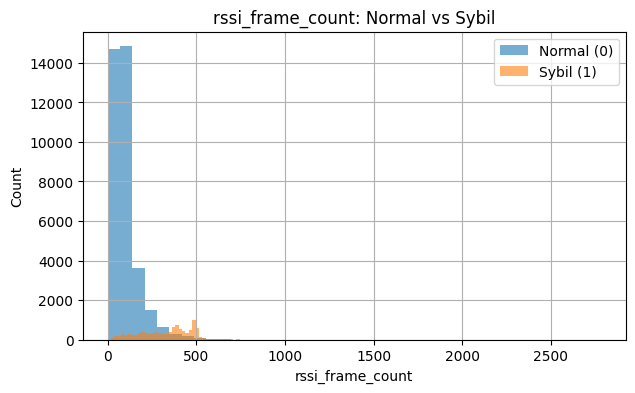

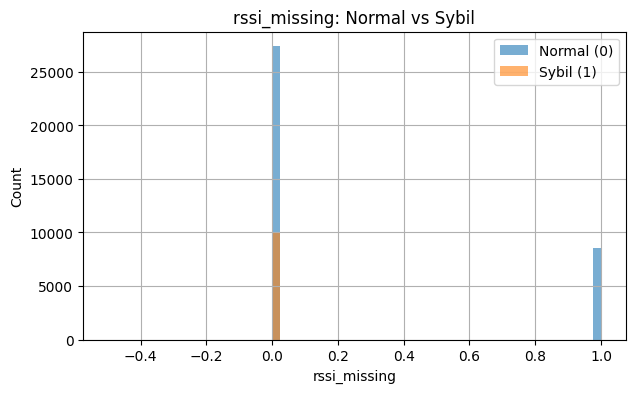

In [45]:
for col in features:

    normal = df[df["label"] == 0][col].dropna()
    sybil  = df[df["label"] == 1][col].dropna()

    plt.figure(figsize=(7,4))

    plt.hist(normal, bins=40, alpha=0.6, label="Normal (0)")
    plt.hist(sybil,  bins=40, alpha=0.6, label="Sybil (1)")

    plt.title(f"{col}: Normal vs Sybil")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)

    plt.show()


How to interpret the graphs

In [46]:
from scipy.stats import wasserstein_distance

scores = []

for col in features:

    n = df[df["label"]==0][col].dropna()
    s = df[df["label"]==1][col].dropna()

    if len(n)>10 and len(s)>10:
        d = wasserstein_distance(n, s)
        scores.append((col, d))

sep = pd.DataFrame(scores, columns=["feature","distance"])
sep.sort_values("distance", ascending=False)


,feature,distance
9,udp_pkt_count,437.304845
14,rssi_frame_count,241.148759
0,pps,87.460969
13,rssi_max,26.038812
12,rssi_min,16.399355
10,rssi_mean,15.713754
4,seq_gap_max,11.605515
3,seq_gap_mean,1.592369
11,rssi_std,1.231380
2,iat_std,0.336898
